# 정적분

$f$가 $[a,b]$에서 연속일 때

$$
\int_a^b f(x)\, dx = F(b) - F(a)
$$

($F'=f$). 부호 있는 넓이(넷 넓이)와 연결된다.

## 1. 기본 계산

In [5]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()
x = sp.symbols('x')

f = 4*x**2 + 3*x + 2
a, b = 0, 1

F = sp.integrate(f, x)
definite = sp.integrate(f, (x, a, b))

print("f(x) =")
display(f)
print("부정적분 F(x) =")
display(F)
print(f"∫_{a}^{b} f dx = F({b})-F({a}) =")
display(definite)
print("검산 F(b)-F(a):")
display(F.subs(x, b) - F.subs(x, a))

f(x) =


부정적분 F(x) =


∫_0^1 f dx = F(1)-F(0) =


검산 F(b)-F(a):


**sp.integrate(f, (x, a, b))**: <br>
=> 정적분 $\int_a^b f\,dx$

**미적분학의 기본정리**: <br>
=> $\int_a^b f = F(b)-F(a)$

## 2. 구간의 성질

$$
\int_a^a f = 0,\quad
\int_a^b f = -\int_b^a f,\quad
\int_a^c f + \int_c^b f = \int_a^b f
$$

In [6]:
f = 4*x**2 + 3*x + 2

# 같은 끝점 → 0 (성질 확인용; 본예는 아님)
print("∫₁¹ =", sp.integrate(f, (x, 1, 1)))

I13 = sp.integrate(f, (x, 1, 3))
I31 = sp.integrate(f, (x, 3, 1))
print("∫₁³ =", I13)
print("∫₃¹ =", I31)
print("∫₁³ == -∫₃¹ ?", I13 == -I31)

I23 = sp.integrate(f, (x, 2, 3))
I35 = sp.integrate(f, (x, 3, 5))
I25 = sp.integrate(f, (x, 2, 5))
print("∫₂³ + ∫₃⁵ =", I23 + I35)
print("∫₂⁵ =", I25)
print("가법성?", I23 + I35 == I25)

∫₁¹ = 0
∫₁³ = 152/3
∫₃¹ = -152/3
∫₁³ == -∫₃¹ ? True
∫₂³ + ∫₃⁵ = 387/2
∫₂⁵ = 387/2
가법성? True


## 3. 넷 넓이 vs 넓이

$f$가 음수인 구간에서는 정적분 기여가 음수.  
실제 넓이(면적)는 $\int |f|$ 또는 부호별로 나눠 더함.

In [7]:
g = x**2 - 4  # [-2,2]에서 x축 아래 있음
signed = sp.integrate(g, (x, -2, 2))
area = sp.integrate(sp.Abs(g), (x, -2, 2))

print("정적분 (부호 포함):")
display(signed)
print("넓이 ∫|g|:")
display(area)

정적분 (부호 포함):


넓이 ∫|g|:


## 4. 그래프: 정적분 = 넷 넓이

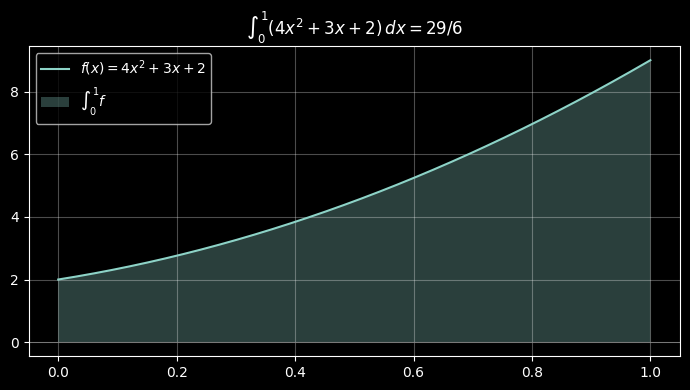

In [8]:
f_num = sp.lambdify(x, f, 'numpy')
xs = np.linspace(0, 1, 200)
ys = f_num(xs)

plt.figure(figsize=(7, 4))
plt.plot(xs, ys, label=r"$f(x)=4x^2+3x+2$")
plt.fill_between(xs, 0, ys, alpha=0.3, label=r"$\int_0^1 f$")
plt.axhline(0, color="gray", lw=0.6)
plt.legend()
plt.grid(True, alpha=0.3)
plt.title(r"$\int_0^1 (4x^2+3x+2)\,dx = $" + str(definite))
plt.tight_layout()
plt.show()